In [1]:
print("Helllo")

Helllo


In [2]:
import pandas as pd

print("Pandas Imported")

Pandas Imported


In [3]:
df = pd.read_csv("../data/clean_stock.csv")

print(df.head())

         Date      Close       High        Low       Open     Volume
0  2020-01-02  72.333878  72.394086  71.091184  71.344054  135480400
1  2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2  2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
3  2020-01-07  71.861832  72.466315  71.642674  72.211033  108872000
4  2020-01-08  73.017815  73.318854  71.565599  71.565599  132079200


In [4]:
import os

print(os.getcwd())

c:\Projects\Stock-Predictive-Dashboard\notebooks


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df.set_index("Date", inplace=True)

In [7]:
stock_df = df.copy()

In [8]:
type(stock_df)

pandas.DataFrame

In [9]:
stock_df.to_csv("../data/stock_features.csv")

In [10]:
from prophet import Prophet

print("Prophet imported successfully!")

Prophet imported successfully!


In [11]:
import pandas as pd

df = pd.read_csv("../data/clean_stock.csv")

df["Date"] = pd.to_datetime(df["Date"])

prophet_df = df[["Date", "Close"]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2020-01-02,72.333878
1,2020-01-03,71.630638
2,2020-01-06,72.201408
3,2020-01-07,71.861832
4,2020-01-08,73.017815


In [12]:
model = Prophet()

model.fit(prophet_df)

14:55:46 - cmdstanpy - INFO - Chain [1] start processing
14:55:48 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

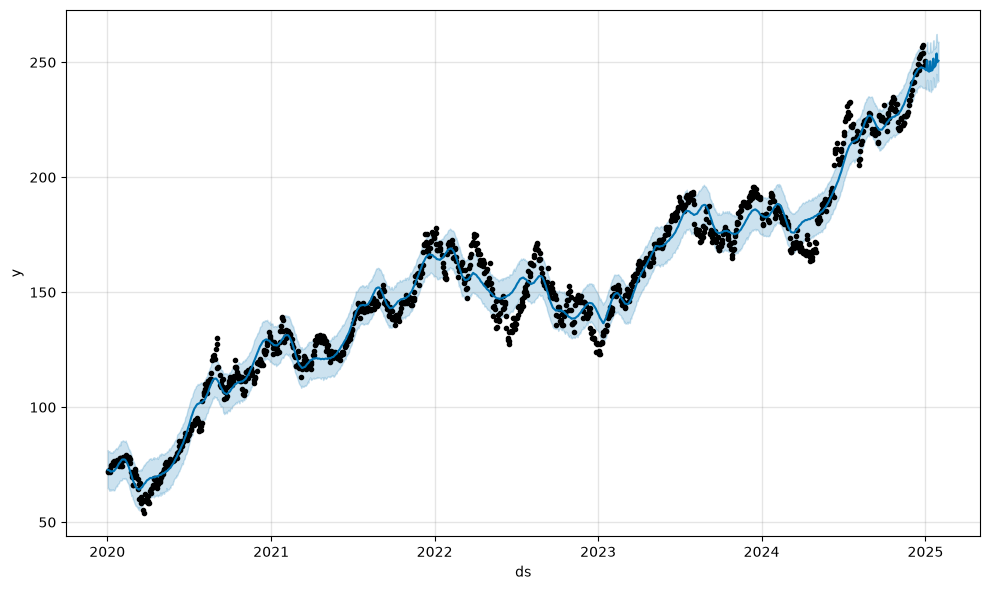

In [14]:
fig = model.plot(forecast)

In [15]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1278,2025-01-21,247.947144,239.100880,255.899345
1279,2025-01-22,248.162530,239.323337,256.843219
1280,2025-01-23,248.391135,239.278656,256.329999
1281,2025-01-24,248.845496,239.981825,257.248050
1282,2025-01-25,253.506339,244.935109,261.984187
1283,2025-01-26,253.844486,244.679657,262.327632
1284,2025-01-27,249.985016,241.210089,258.862654
1285,2025-01-28,250.254552,242.204328,258.837720
1286,2025-01-29,250.461920,242.048071,258.712878
1287,2025-01-30,250.649380,241.822630,258.985555


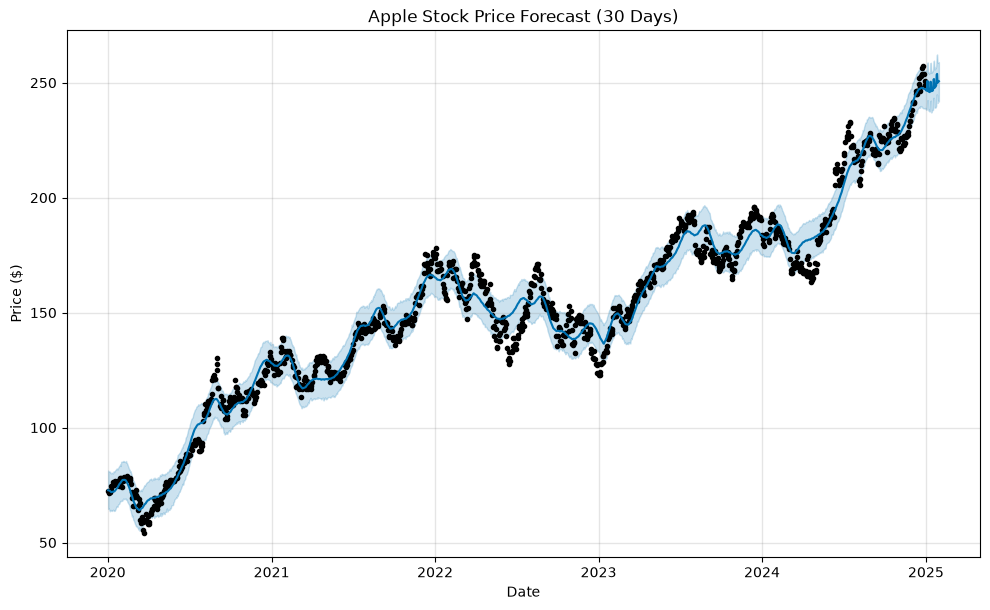

In [16]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)

plt.title("Apple Stock Price Forecast (30 Days)")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.show()

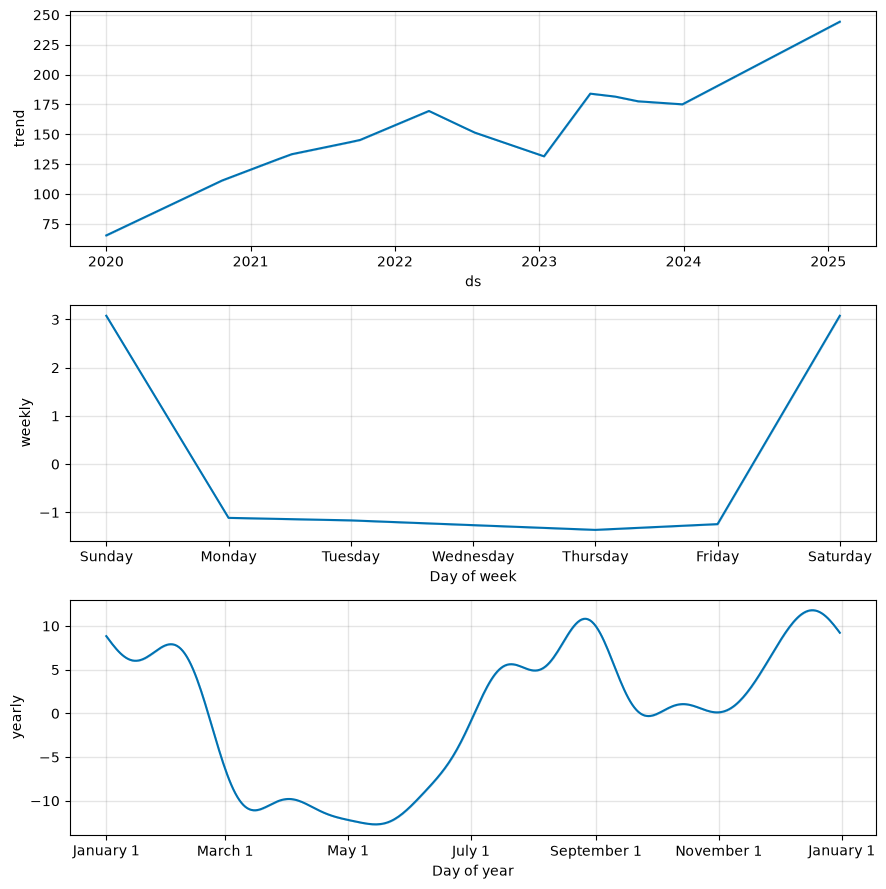

In [ ]:
fig2 = model.plot_components(forecast)

plt.show()

In [18]:
forecast.to_csv("../data/forecast.csv", index=False)

In [20]:
import pandas as pd

df = pd.read_csv("../data/stock_features.csv")
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [21]:
stock_df = df.copy()

stock_df["MA20"] = stock_df["Close"].rolling(20).mean()

stock_df["MA50"] = stock_df["Close"].rolling(50).mean()

stock_df["Daily_Return"] = stock_df["Close"].pct_change()

stock_df["Volatility"] = stock_df["Daily_Return"].rolling(20).std()

stock_df["Lag_1"] = stock_df["Close"].shift(1)

stock_df["Lag_2"] = stock_df["Close"].shift(2)

stock_df["Lag_3"] = stock_df["Close"].shift(3)

stock_df = stock_df.dropna()

In [22]:
stock_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50',
       'Daily_Return', 'Volatility', 'Lag_1', 'Lag_2', 'Lag_3'],
      dtype='str')

In [23]:
stock_df.reset_index(drop=True).to_csv(
    "../data/stock_features.csv",
    index=False
)

In [24]:
check_df = pd.read_csv("../data/stock_features.csv")
print(check_df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'Daily_Return', 'Volatility', 'Lag_1', 'Lag_2', 'Lag_3']
